# O09e Fringes of Equal Thickness  
## Yaman Ajaj (3722952) ;  Guilherme Schewtschik (3748052)

## 1.The Setup:  
In this experiment, we investigated the interference patterns known as fringes of equal thickness using the Abbe comparator—an optical precision instrument consisting of dual microscopes and a precision scale with $0.2$ µm resolution. The measurements were carried out in one direction to minimize systematic errors due to table movement.  
We performed two main experiments:

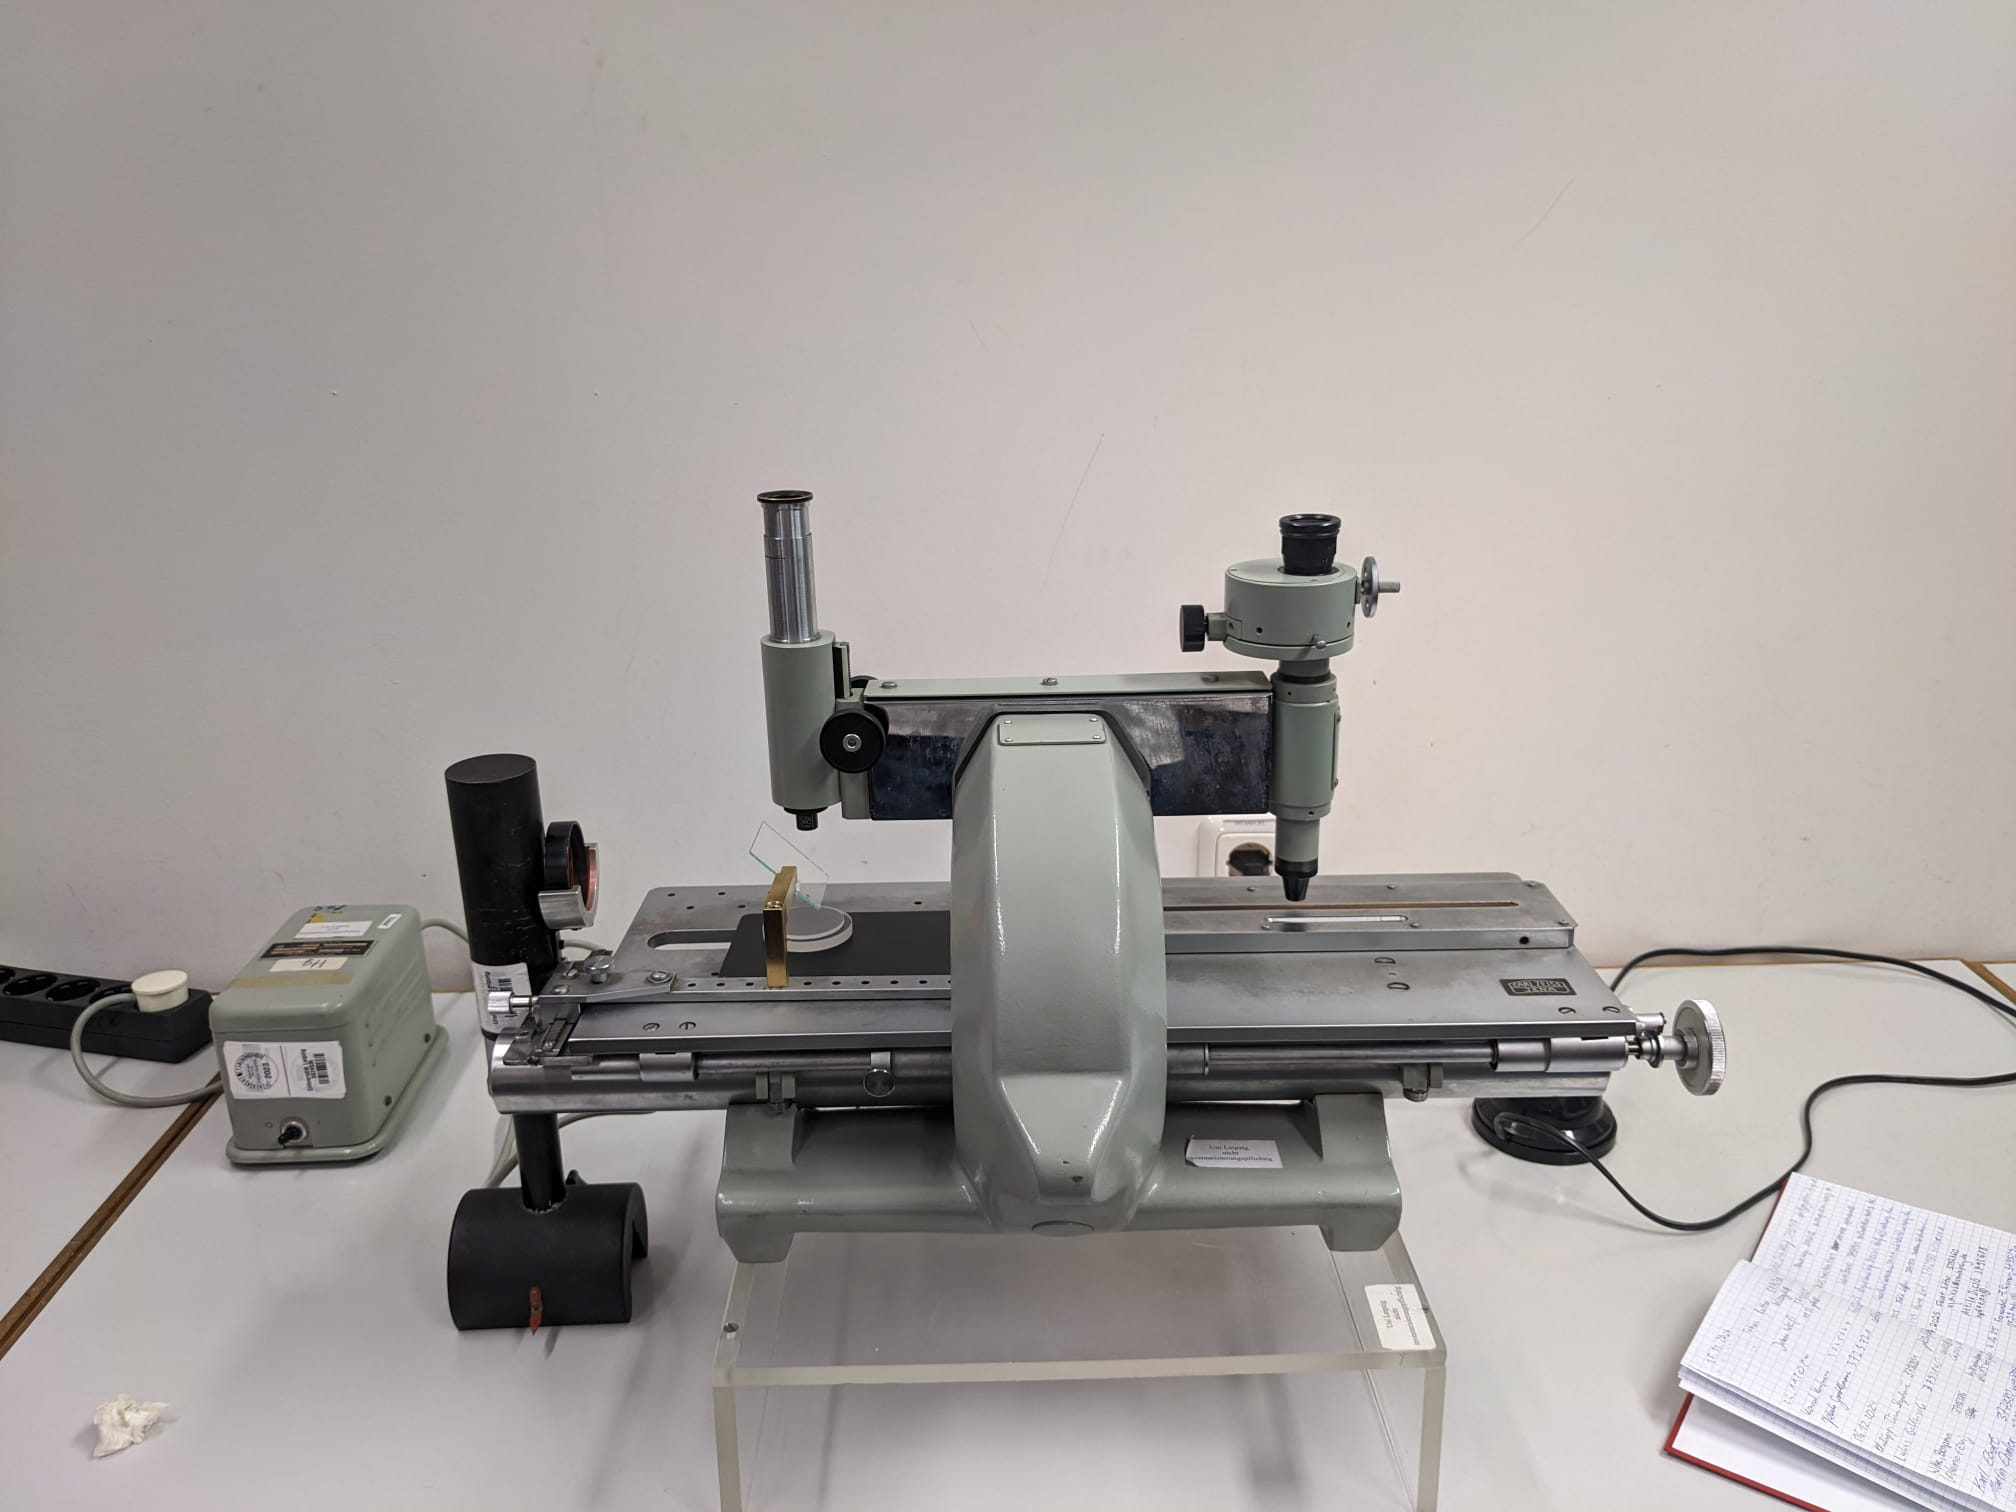

In [32]:
from IPython.display import display, Image
display(Image(filename='Abbe_refractometer.png', width=600))


### Task 1:  
Measurement of Newton’s Rings formed between a convex lens and a glass plate, using monochromatic light. The objective was to determine the radius of curvature of the lens.  


### Task 2:  
Measurement of interference fringes in wedge-shaped air films, created using a metal foil and a strand of hair between two glass plates, to determine the thickness of these objects.

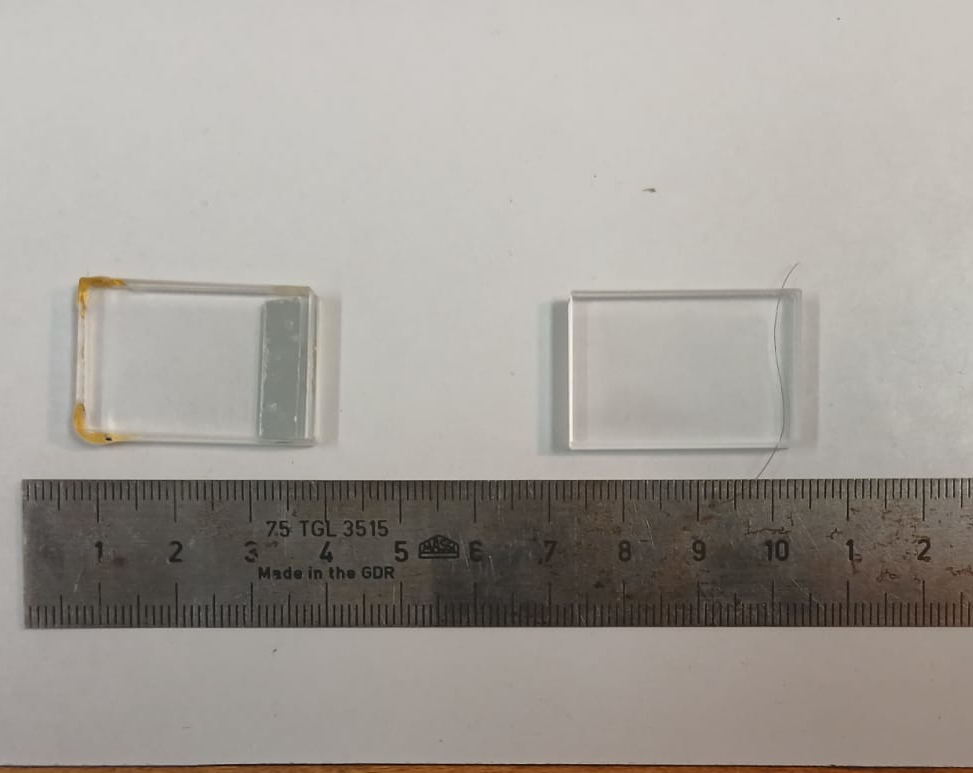

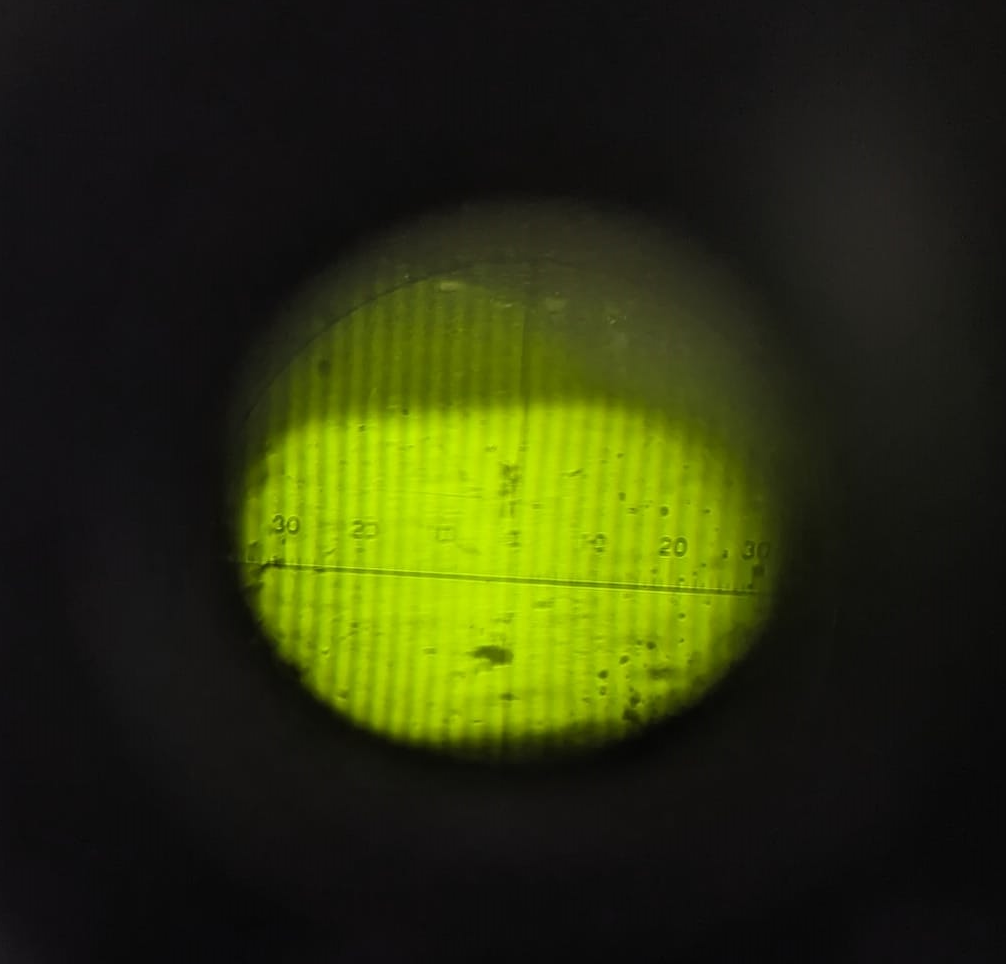

In [33]:
display(Image(filename='Al_foil_and_Hair.png', width=600))
display(Image(filename='Lines_task2.png', width=600))

## 2. Theoretical Background:  
### 2.1 Newton’s Rings (Task 1):  
Newton’s Rings result from the interference of light reflecting off the top and bottom surfaces of the thin air film between a convex lens and a flat glass plate. Due to the curvature of the lens, the thickness of the air gap varies radially. The optical path difference between interfering rays leads to constructive or destructive interference, forming concentric rings.  
For destructive interference (dark rings), the squared radius $r_k^2$ of the $k-th$ dark fringe is related to the radius of curvature $R$ of the lens by:  
$$r_k^2 = k\lambda R + 2d_0R - \lambda R $$  
Here, $\lambda$ is the wavelength of the light used, and $d_0$ is a small offset due to imperfect contact.  
Plotting $r_k^2$ vs. $k$ yields a linear relation. The slope of this graph is $λR$, allowing us to compute the lens radius.

### 2.2 Wedge-Shaped Interference (Task 2):  
In this setup, two glass plates are separated by a thin object (e.g., a foil or hair), forming a wedge-shaped air film. Monochromatic light reflected from the top and bottom surfaces of the air wedge produces interference fringes.  
The horizontal positions $x_k$ of the fringes follow a linear pattern:  
$$x_k = \frac{k \lambda l}{2D} $$  
Where:  
- $l$ is the length of the wedge.
- $D$ is the thickness of the inserted object.  
By plotting fringe position $x_k$ vs. fringe number $k$, and using the slope $A$, we can determine $D=\frac{\lambda l}{2A}$.

## 3. Data Analysis:  
The analysis was performed using Python. Data was imported from an Excel file containing measurements for both tasks.  
### Task 1: Newton’s Rings:  
- Measure from the right highest (10th ring) order to the left highest order (10th ring). Calculate the diameter from the difference of the readings: $|le_{10} - ri_{10}| = 2r_{10}$
- Converted diameters to radii, squared them, and performed linear regression.
- Wavelength used: extracted from the dataset and converted to meters.

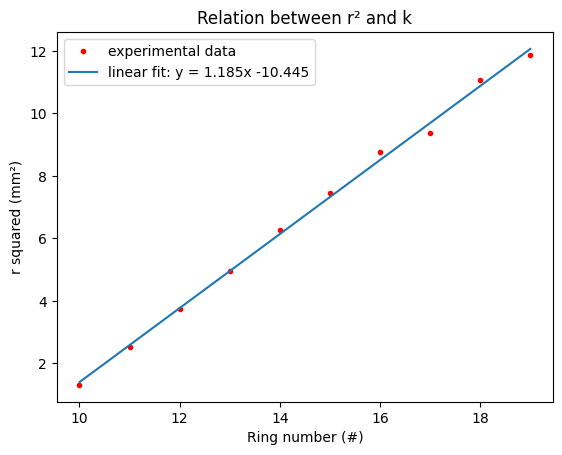

Task 1: A1 = 1.185 μm , B1 = -10.445 mm² 
R = 2.011 m, d0 = -2.302 μm


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#Data import
data1_pd = pd.read_excel('Data.xlsx', sheet_name='Task1')
data1 = data1_pd.to_numpy()

data2_pd = pd.read_excel('Data.xlsx', sheet_name='Task2')
data2 = data2_pd.to_numpy()

##Task1
#distance of the dark rings
d = data1[:,1].astype(float)*1e-3

#calculations
dr = np.flip(d[0:10]) 
dl = d[10:20]

d = (dl-dr)/2

index = np.arange(10,20)
index_T = index.reshape((-1,1))

#wavelength of the light
lamb = data1[2,6]*1e-9

#calculations
d2 = d**2

#linear regression results

model1 = LinearRegression().fit(index_T,d2)

A1 = model1.coef_[0]
B1 = model1.intercept_

#calculated results
R = A1/lamb
d0 = 0.5*((B1/R)+lamb)

#float formating for the graph
A1_graph = "%.3f"%(A1*1e6)
B1_graph = "%.3f"%(B1*1e6)

#plotting
plt.figure(1)
plt.title('Relation between r² and k')
plt.xlabel('Ring number (#)')
plt.ylabel('r squared (mm²)')

plt.plot(index, d2*1e6, '.', color='red', label = 'experimental data')
plt.plot(index, model1.predict(index_T)*1e6, label = f'linear fit: y = {A1_graph}x {B1_graph}')
plt.legend(loc = 'upper left')

plt.show()

print(f'Task 1: A1 = {A1_graph} μm , B1 = {B1_graph} mm² \nR = {"%.3f"%(R)} m, d0 = {"%.3f"%(d0*1e6)} μm')

Wavelength used:  
$$\lambda = 588 nm = 5.88 \times 10^{-7} m $$  

R and $d_0$ are is calculated by:



$R = A_1/\lambda$

$d_0 = 1/2(B_1/R + \lambda)$

Results:

$R = 2.011 m$ 

$d_0 = 2.449 \mu m$ 

A $d_0$ smaller than 0 is interpreted to be an indent on the glass surface.

### Task 2: Wedge Interference:  
For both aluminium foil and hair:  
- Measured 10 fringe positions.
- Performed linear regressions to get slopes $A_2$ (Al foil) and $A_3$ (hair).
- Used known wedge length $l$ and light wavelength to compute thickness.

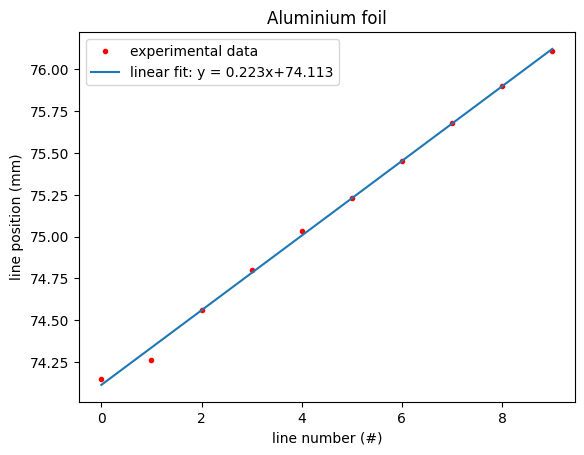

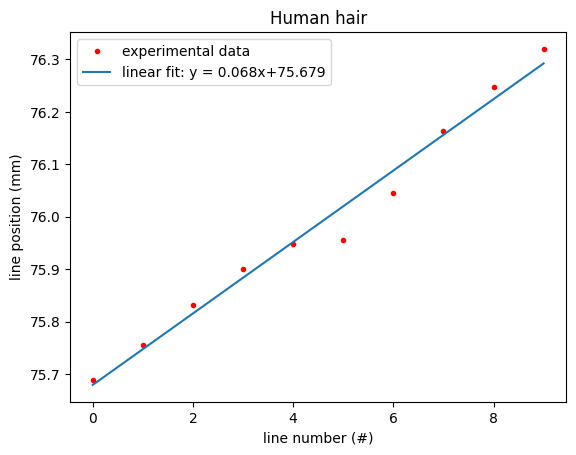

Task 2: Thickness Aluminum foil: 30.335 μm, Thickness Hair: 125.367 μm


In [15]:
##Task2
#distance of the dark lines

d_Al = data2[:,1]*1e-3
d_Hair = data2[:,2]*1e-3

I_Al = data2[1,4]*1e-2
I_Hair = data2[3,4]*1e-2

index2 = np.arange(0,10)
index2_T = index2.reshape((-1,1))

#linear fit
model2 = LinearRegression().fit(index2_T,d_Al)
model3 = LinearRegression().fit(index2_T,d_Hair)

#linear regression results
A2 = model2.coef_[0]
B2 = model2.intercept_

A3 = model3.coef_[0]
B3 = model3.intercept_

#calculations
D_Al = (I_Al*lamb)/(2*A2)
D_Hair = (I_Hair*lamb)/(2*A3)

#float formating for the graph
A2_graph = "%.3f"%(A2*1e3)
B2_graph = "%.3f"%(B2*1e3)

A3_graph = "%.3f"%(A3*1e3)
B3_graph = "%.3f"%(B3*1e3)


#plotting
plt.figure(2)
plt.title('Aluminium foil')
plt.xlabel('line number (#)')
plt.ylabel('line position (mm)')

plt.plot(index2, d_Al*1e3, '.', color='red', label = 'experimental data')
plt.plot(index2, model2.predict(index2_T)*1e3, label = f'linear fit: y = {A2_graph}x+{B2_graph}')
plt.legend(loc = 'upper left')


plt.figure(3)
plt.title('Human hair')
plt.xlabel('line number (#)')
plt.ylabel('line position (mm)')

plt.plot(index2, d_Hair*1e3, '.', color='red', label = 'experimental data')
plt.plot(index2, model3.predict(index2_T)*1e3, label = f'linear fit: y = {A3_graph}x+{B3_graph}')
plt.legend(loc = 'upper left')

plt.show()

print(f'Task 2: Thickness Aluminum foil: {"%.3f"%(D_Al*1e6)} μm, Thickness Hair: {"%.3f"%(D_Hair*1e6)} μm')

We can calculate the thickness of the material through:

$$D = \frac{l \lambda}{2A} $$

With the calculated results we get:

$D_{al}= 30.355 \mu m$

$D_{Hair} = 125.367 \mu m$